# 01 · Data exploration
First look at the nflverse schedule and play-by-play data.

In [1]:
import sys; sys.path.append('..')
import pandas as pd
import matplotlib.pyplot as plt
from src.data_loader import load_schedules, load_pbp

sched = load_schedules()
sched.shape

(7548, 46)

## Games and home-field advantage by season

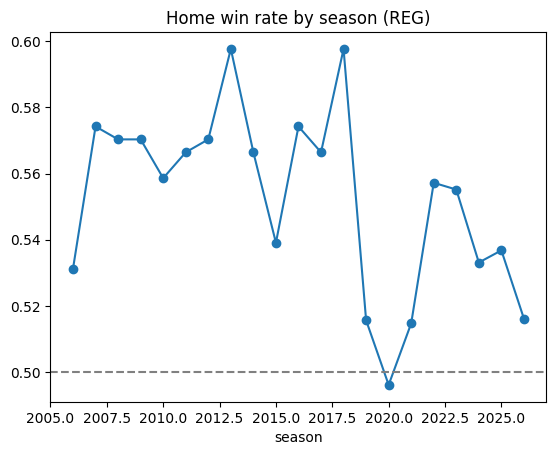

season
2006    0.531
2007    0.574
2008    0.570
2009    0.570
2010    0.559
2011    0.566
2012    0.570
2013    0.598
2014    0.566
2015    0.539
2016    0.574
2017    0.566
2018    0.598
2019    0.516
2020    0.496
2021    0.515
2022    0.557
2023    0.555
2024    0.533
2025    0.537
2026    0.516
Name: home_win, dtype: float64

In [2]:
games = sched[(sched.season >= 2006) & sched.home_score.notna()].copy()
games['home_win'] = (games.home_score > games.away_score).astype(int)
reg = games[games.game_type == 'REG']
hfa = reg.groupby('season').home_win.mean()
hfa.plot(marker='o', title='Home win rate by season (REG)'); plt.axhline(0.5, ls='--', c='gray'); plt.show()
hfa.round(3)

## Vegas benchmark
`spread_line` is from the home team's perspective (positive = home favored). How often does the favorite win?

In [3]:
v = reg[reg.spread_line != 0]
fav_home = v.spread_line > 0
fav_won = (fav_home & (v.home_win == 1)) | (~fav_home & (v.home_win == 0))
print(f'Vegas favorite win rate: {fav_won.mean():.3f} over {len(v)} games')

Vegas favorite win rate: 0.665 over 5226 games


## Play-by-play sample

In [4]:
cols = ['game_id','season','week','posteam','defteam','play_type','epa','success','pass','rush','interception','fumble_lost']
pbp = load_pbp([2025], columns=cols)
plays = pbp[pbp.play_type.isin(['pass','run'])]
off = plays.groupby('posteam').epa.mean().sort_values(ascending=False)
off.head(10)

posteam
LA     0.144526
BUF    0.137576
GB     0.121635
DAL    0.097834
NE     0.090326
DET    0.082203
CHI    0.073621
IND    0.072121
SF     0.061053
SEA    0.044796
Name: epa, dtype: float64